In [ ]:
# !pip install pyomo highspy networkx matplotlib

In [ ]:
import itertools
import math
import matplotlib.pyplot as plt
import networkx as nx
import pyomo.environ as pyo
from pyomo.contrib.appsi.solvers import Highs


=== Example 1: Erdős–Rényi, Case 1 ===
Objective: 0.0
Deleted: [0, 1]
Connected terminal pairs: []
Terminal components: [[2], [4], [7]]


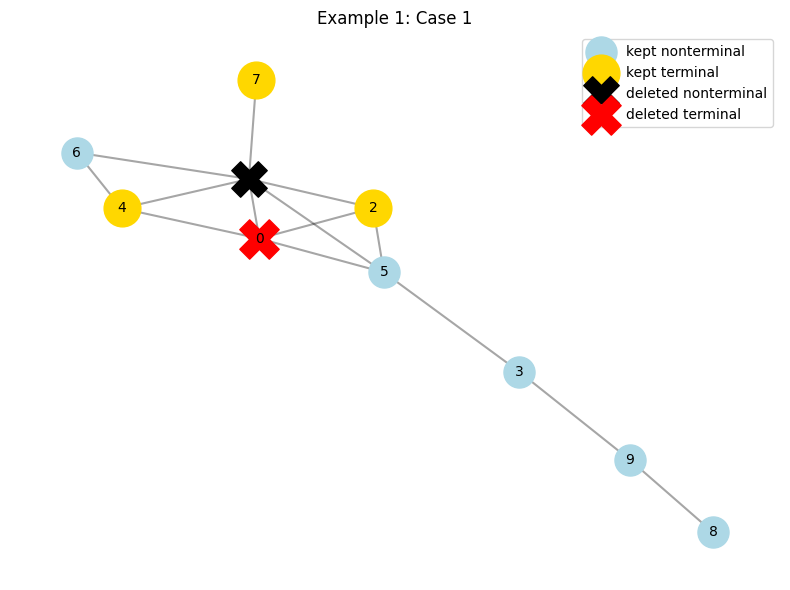


=== Example 2: Barabási–Albert, Case 2 ===
Objective: 10.0
Deleted: []
Connected terminal pairs: [(0, 1), (0, 2), (0, 3), (0, 4), (1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]
Terminal components: [[0, 1, 2, 3, 4]]


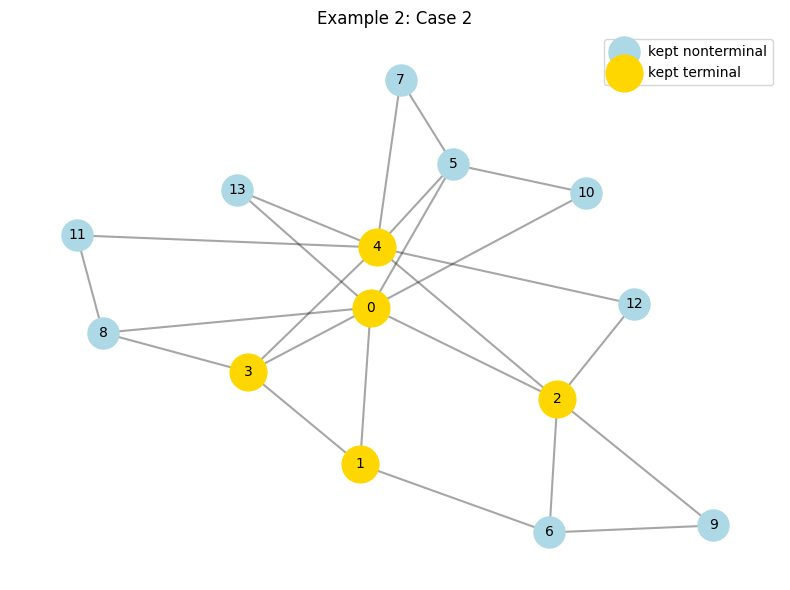


=== Example 3: Custom graph, Case 2 ===
Objective: 3.0
Deleted: [1, 7]
Connected terminal pairs: [(3, 4), (3, 9), (4, 9)]
Terminal components: [[0], [3, 4, 9], [6]]


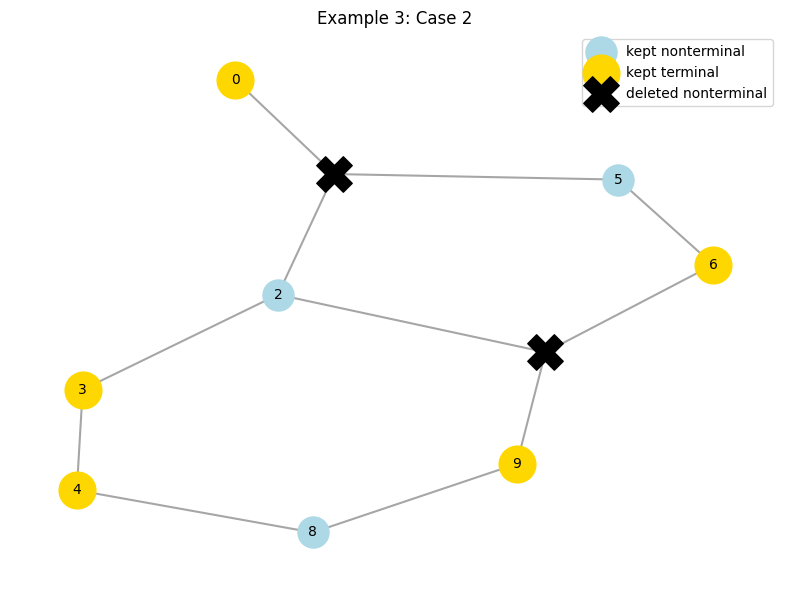

In [ ]:
def build_ecndp_model(G, terminals, K, case=1):

    if not isinstance(G, nx.Graph) or G.is_directed():
        raise ValueError("G must be an undirected networkx.Graph")

    nodes = sorted(G.nodes())
    T = set(terminals)

    if not T.issubset(set(nodes)):
        raise ValueError("terminals must be a subset of G.nodes()")

    if case not in (1, 2):
        raise ValueError("case must be 1 or 2")

    if K < 0:
        raise ValueError("K must be nonnegative")

    if case == 1 and K > len(nodes):
        raise ValueError("For case 1, K cannot exceed |V|")

    nonterminals = [v for v in nodes if v not in T]
    if case == 2 and K > len(nonterminals):
        raise ValueError("For case 2, K cannot exceed |V \\ T|")

    pairs = list(itertools.combinations(nodes, 2))
    terminal_pairs = [(i, j) for (i, j) in pairs if i in T and j in T]
    triples = list(itertools.combinations(nodes, 3))
    edges = [tuple(sorted(e)) for e in G.edges()]

    m = pyo.ConcreteModel()

    m.V = pyo.Set(initialize=nodes)
    m.P = pyo.Set(dimen=2, initialize=pairs)
    m.E = pyo.Set(dimen=2, initialize=edges)
    m.TP = pyo.Set(dimen=2, initialize=terminal_pairs)
    m.TR = pyo.Set(dimen=3, initialize=triples)

    m.s = pyo.Var(m.V, domain=pyo.Binary)      # 1 if node deleted
    m.x = pyo.Var(m.P, domain=pyo.Binary)      # 1 if pair is connected in residual graph

    # Objective: minimize connected terminal pairs
    m.obj = pyo.Objective(
        expr=sum(m.x[i, j] for (i, j) in m.TP),
        sense=pyo.minimize
    )

    # Budget
    if case == 1:
        m.budget = pyo.Constraint(expr=sum(m.s[v] for v in m.V) <= K)
    else:
        m.budget = pyo.Constraint(expr=sum(m.s[v] for v in nonterminals) <= K)
        m.protect = pyo.Constraint(T, rule=lambda m, t: m.s[t] == 0)

    # Surviving adjacent vertices must be connected
    m.edge_link = pyo.Constraint(
        m.E,
        rule=lambda m, i, j: m.x[i, j] >= 1 - m.s[i] - m.s[j]
    )

    # Deleted vertices cannot be connected to anyone
    m.upper1 = pyo.Constraint(
        m.P,
        rule=lambda m, i, j: m.x[i, j] <= 1 - m.s[i]
    )
    m.upper2 = pyo.Constraint(
        m.P,
        rule=lambda m, i, j: m.x[i, j] <= 1 - m.s[j]
    )

    # Corrected triangle inequalities for all i < j < k
    m.tri1 = pyo.Constraint(
        m.TR,
        rule=lambda m, i, j, k: m.x[i, j] + m.x[j, k] - m.x[i, k] <= 1
    )
    m.tri2 = pyo.Constraint(
        m.TR,
        rule=lambda m, i, j, k: m.x[i, j] + m.x[i, k] - m.x[j, k] <= 1
    )
    m.tri3 = pyo.Constraint(
        m.TR,
        rule=lambda m, i, j, k: m.x[i, k] + m.x[j, k] - m.x[i, j] <= 1
    )

    return m


def solve_ecndp_highs(G, terminals, K, case=1, mip_gap=0.0, stream_solver=False):

    model = build_ecndp_model(G, terminals, K, case=case)

    solver = Highs()
    solver.config.mip_gap = mip_gap
    solver.config.stream_solver = stream_solver

    results = solver.solve(model)

    deleted = sorted(v for v in model.V if pyo.value(model.s[v]) > 0.5)
    kept = sorted(v for v in model.V if pyo.value(model.s[v]) <= 0.5)

    terminal_pairs_connected = sorted(
        (i, j) for (i, j) in model.TP if pyo.value(model.x[i, j]) > 0.5
    )

    residual = G.subgraph(kept).copy()
    comp_list = list(nx.connected_components(residual))

    terminal_components = []
    for comp in comp_list:
        comp_terminals = sorted(set(comp) & set(terminals))
        if comp_terminals:
            terminal_components.append(comp_terminals)

    out = {
        "model": model,
        "results": results,
        "objective": pyo.value(model.obj),
        "deleted": deleted,
        "kept": kept,
        "connected_terminal_pairs": terminal_pairs_connected,
        "terminal_components": terminal_components,
    }
    return out


def draw_solution(G, terminals, deleted, title=None, seed=7):

    T = set(terminals)
    D = set(deleted)
    K = set(G.nodes()) - D

    surviving_terminals = sorted(T & K)
    surviving_nonterminals = sorted(K - T)
    deleted_terminals = sorted(T & D)
    deleted_nonterminals = sorted(D - T)

    pos = nx.spring_layout(G, seed=seed)

    plt.figure(figsize=(8, 6))
    nx.draw_networkx_edges(G, pos, alpha=0.35, width=1.5)

    if surviving_nonterminals:
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=surviving_nonterminals,
            node_size=500,
            node_color="lightblue",
            label="kept nonterminal"
        )

    if surviving_terminals:
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=surviving_terminals,
            node_size=700,
            node_color="gold",
            label="kept terminal"
        )

    if deleted_nonterminals:
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=deleted_nonterminals,
            node_size=650,
            node_color="black",
            node_shape="X",
            label="deleted nonterminal"
        )

    if deleted_terminals:
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=deleted_terminals,
            node_size=800,
            node_color="red",
            node_shape="X",
            label="deleted terminal"
        )

    nx.draw_networkx_labels(G, pos, font_size=10)

    plt.title(title or "ECNDP solution")
    plt.axis("off")
    plt.legend()
    plt.tight_layout()
    plt.show()


def run_demo():
    # Example 1: small random graph
    G1 = nx.erdos_renyi_graph(n=10, p=0.28, seed=4)
    terminals1 = {0, 2, 4, 7}
    K1 = 2

    sol1 = solve_ecndp_highs(G1, terminals1, K1, case=1, mip_gap=0.0, stream_solver=False)
    print("=== Example 1: Erdős–Rényi, Case 1 ===")
    print("Objective:", sol1["objective"])
    print("Deleted:", sol1["deleted"])
    print("Connected terminal pairs:", sol1["connected_terminal_pairs"])
    print("Terminal components:", sol1["terminal_components"])
    draw_solution(G1, terminals1, sol1["deleted"], title="Example 1: Case 1")

    # Example 2: Barabási–Albert, terminals protected
    G2 = nx.barabasi_albert_graph(n=14, m=2, seed=5)
    terminals2 = {0, 1, 2, 3, 4}
    K2 = 3

    sol2 = solve_ecndp_highs(G2, terminals2, K2, case=2, mip_gap=0.0, stream_solver=False)
    print("\n=== Example 2: Barabási–Albert, Case 2 ===")
    print("Objective:", sol2["objective"])
    print("Deleted:", sol2["deleted"])
    print("Connected terminal pairs:", sol2["connected_terminal_pairs"])
    print("Terminal components:", sol2["terminal_components"])
    draw_solution(G2, terminals2, sol2["deleted"], title="Example 2: Case 2")

    # Example 3: your own graph
    G3 = nx.Graph()
    G3.add_edges_from([
        (0, 1), (1, 2), (2, 3), (3, 4),
        (1, 5), (5, 6), (6, 7), (2, 7),
        (4, 8), (8, 9), (7, 9)
    ])
    terminals3 = {0, 3, 4, 6, 9}
    K3 = 2

    sol3 = solve_ecndp_highs(G3, terminals3, K3, case=2, mip_gap=0.0, stream_solver=False)
    print("\n=== Example 3: Custom graph, Case 2 ===")
    print("Objective:", sol3["objective"])
    print("Deleted:", sol3["deleted"])
    print("Connected terminal pairs:", sol3["connected_terminal_pairs"])
    print("Terminal components:", sol3["terminal_components"])
    draw_solution(G3, terminals3, sol3["deleted"], title="Example 3: Case 2")


if __name__ == "__main__":
    run_demo()

In [7]:
G = nx.Graph()
G.add_edges_from([
    (1, 2), (2, 3), (3, 4), (2, 5), (5, 6), (4, 6)
])

terminals = {1, 3, 6}
K = 1

sol = solve_ecndp_highs(G, terminals, K, case=2)
print(sol["objective"])
print(sol["deleted"])

1.0
[2]
